<h1>Conditional Graph</h1>

In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [14]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    result: int

In [ ]:
def adder(state:AgentState)-> AgentState:
    """ This node is performing addition operation """
    state['result'] = state['number1'] + state['number2']
    return state

In [16]:
def subtractor(state:AgentState)-> AgentState:
    """ This node is performing subtraction operation """
    state['result'] = state['number1'] - state['number2']
    return state

In [17]:
def decide_next_node(state:AgentState)->AgentState:
    """This node will select the next node of the graph"""
    if state['operation'] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"
    
    

In [18]:
graph = StateGraph(AgentState)

graph.add_node("add_node",adder)
graph.add_node("sub_node",subtractor)
graph.add_node("router", lambda state:state) #passthrought function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge:node
        "addition_operation": "add_node",
        "subtraction_operation": "sub_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("sub_node",END)

app = graph.compile()

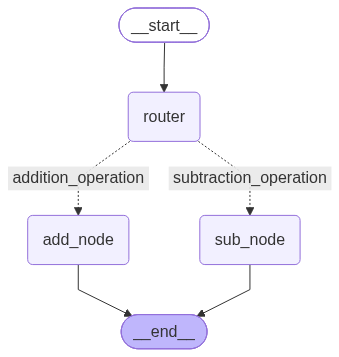

In [19]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
add_condition = AgentState(number1=10,number2=5,operation="+")
result = app.invoke(add_condition)
result

{'number1': 10, 'operation': '+', 'number2': 5, 'result': 15}

In [24]:
sub_condition = AgentState(number1=10,number2=5,operation="-")
result = app.invoke(sub_condition)
result['result']

5

Exercise

In [25]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    result1: int
    result2: int

In [26]:
def adder1(state:AgentState)-> AgentState:
    """ This node is performing addition operation """
    state['result1'] = state['number1'] + state['number2']
    return state

def subtractor1(state:AgentState)-> AgentState:
    """ This node is performing subtraction operation """
    state['result1'] = state['number1'] - state['number2']
    return state

def adder2(state:AgentState)-> AgentState:
    """ This node is performing addition operation """
    state['result2'] = state['number3'] + state['number4']
    return state

def subtractor2(state:AgentState)-> AgentState:
    """ This node is performing subtraction operation """
    state['result2'] = state['number3'] - state['number4']
    return state

In [27]:
def decide_next_node(state:AgentState)->AgentState:
    """This node will select the next node of the graph"""
    if state['operation'] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"

In [28]:
graph = StateGraph(AgentState)

graph.add_node("add_node",adder1)
graph.add_node("sub_node",subtractor1)
graph.add_node("add_node2",adder2)
graph.add_node("sub_node2",subtractor2)
graph.add_node("router", lambda state:state) #passthrought function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge:node
        "addition_operation": "add_node",
        "subtraction_operation": "sub_node"
    }
)



graph.add_node("router2", lambda state:state) #passthrought function

graph.add_conditional_edges(
    "router2",
    decide_next_node,
    {
        # Edge:node
        "addition_operation": "add_node2",
        "subtraction_operation": "sub_node2"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("sub_node","router2")

graph.add_edge("add_node2", END)
graph.add_edge("sub_node2",END)
app = graph.compile()

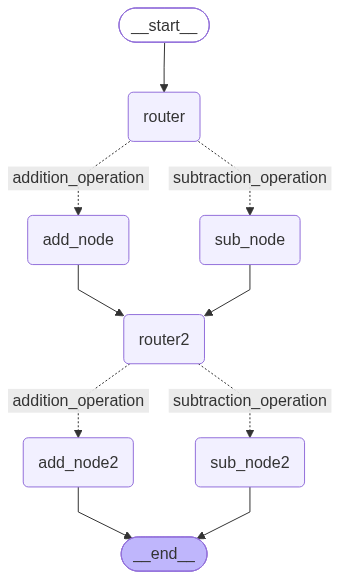

In [29]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))